<h2> Book Sales</h2>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
df = pd.read_csv("Books_Data_Clean.csv")
df.head()

,index,Publishing Year,Book Name,Author,language_code,Author_Rating,Book_average_rating,Book_ratings_count,genre,gross sales,publisher revenue,sale price,sales rank,Publisher,units sold
0,0,1975.0,Beowulf,"Unknown, Seamus Heaney",en-US,Novice,3.42,155903,genre fiction,34160.0,20496.0,4.88,1,HarperCollins Publishers,7000
1,1,1987.0,Batman: Year One,"Frank Miller, David Mazzucchelli, Richmond Lew...",eng,Intermediate,4.23,145267,genre fiction,12437.5,7462.5,1.99,2,HarperCollins Publishers,6250
2,2,2015.0,Go Set a Watchman,Harper Lee,eng,Novice,3.31,138669,genre fiction,47795.0,28677.0,8.69,3,"Amazon Digital Services, Inc.",5500
3,3,2008.0,When You Are Engulfed in Flames,David Sedaris,en-US,Intermediate,4.04,150898,fiction,41250.0,24750.0,7.50,3,Hachette Book Group,5500
4,4,2011.0,Daughter of Smoke & Bone,Laini Taylor,eng,Intermediate,4.04,198283,genre fiction,37952.5,22771.5,7.99,4,Penguin Group (USA) LLC,4750


In [5]:
df.describe()

,index,Publishing Year,Book_average_rating,Book_ratings_count,gross sales,publisher revenue,sale price,sales rank,units sold
count,1070.000000,1069.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000
mean,534.500000,1971.377923,4.007000,94909.913084,1856.622944,843.281030,4.869561,611.652336,9676.980374
std,309.026698,185.080257,0.247244,31513.242518,3936.924240,2257.596743,3.559919,369.849830,15370.571306
min,0.000000,-560.000000,2.970000,27308.000000,104.940000,0.000000,0.990000,1.000000,106.000000
25%,267.250000,1985.000000,3.850000,70398.000000,372.465000,0.000000,1.990000,287.500000,551.250000
50%,534.500000,2003.000000,4.015000,89309.000000,809.745000,273.078000,3.990000,595.500000,3924.000000
75%,801.750000,2010.000000,4.170000,113906.500000,1487.957500,721.180500,6.990000,932.500000,5312.250000
max,1069.000000,2016.000000,4.770000,206792.000000,47795.000000,28677.000000,33.860000,1273.000000,61560.000000


In [22]:
# Getting rid of negative values
df = df[df["Publishing Year"] > 1900]
df.describe()


,index,Publishing Year,Book_average_rating,Book_ratings_count,gross sales,publisher revenue,sale price,sales rank,units sold
count,1009.000000,1009.000000,1009.000000,1009.000000,1009.000000,1009.000000,1009.000000,1009.000000,1009.000000
mean,535.926660,1994.730426,4.012230,94817.793855,1832.644985,841.360638,4.844311,613.314172,9744.482656
std,308.769358,23.204719,0.246492,31473.890412,3947.885096,2279.579848,3.561712,369.628663,15350.021050
min,0.000000,1901.000000,2.970000,27308.000000,104.940000,0.000000,0.990000,1.000000,106.000000
25%,271.000000,1989.000000,3.860000,70701.000000,366.300000,0.000000,1.990000,291.000000,570.000000
50%,535.000000,2003.000000,4.030000,89204.000000,792.000000,273.240000,3.990000,596.000000,3942.000000
75%,802.000000,2010.000000,4.180000,113400.000000,1470.260000,714.756000,6.990000,933.000000,5427.000000
max,1069.000000,2016.000000,4.770000,206792.000000,47795.000000,28677.000000,33.860000,1273.000000,61560.000000


In [24]:
# Checking for null values
df.isna().sum()

index                   0
Publishing Year         0
Book Name              21
Author                  0
language_code          49
Author_Rating           0
Book_average_rating     0
Book_ratings_count      0
genre                   0
gross sales             0
publisher revenue       0
sale price              0
sales rank              0
Publisher               0
units sold              0
dtype: int64

In [27]:
# drop the one that has no book name
df.dropna(subset = "Book Name",inplace = True)
df.isna().sum()

index                   0
Publishing Year         0
Book Name               0
Author                  0
language_code          47
Author_Rating           0
Book_average_rating     0
Book_ratings_count      0
genre                   0
gross sales             0
publisher revenue       0
sale price              0
sales rank              0
Publisher               0
units sold              0
dtype: int64

In [29]:
# Check for duplicated values
df.duplicated()
# We have no duplicate values

0       False
1       False
2       False
3       False
4       False
        ...  
1065    False
1066    False
1067    False
1068    False
1069    False
Length: 988, dtype: bool

In [30]:
df.duplicated().sum() # sum of dublicated values

np.int64(0)

In [31]:
# check for unique entries in each coulum
df.nunique()

index                  988
Publishing Year        101
Book Name              987
Author                 669
language_code            8
Author_Rating            4
Book_average_rating    133
Book_ratings_count     983
genre                    4
gross sales            774
publisher revenue      570
sale price             143
sales rank             818
Publisher                9
units sold             470
dtype: int64

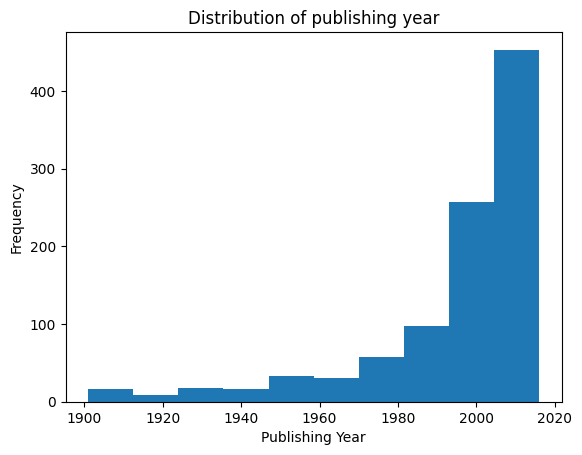

In [32]:
# creat a histogram of the Publishing year
plt.hist(df["Publishing Year"])
plt.xlabel("Publishing Year")
plt.ylabel("Frequency")
plt.title("Distribution of publishing year")
plt.show()

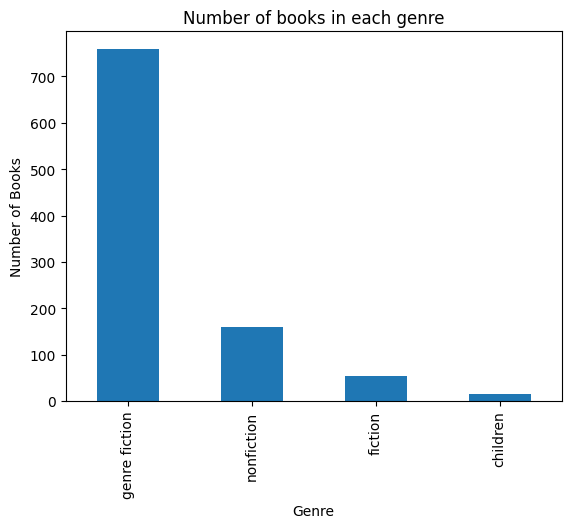

In [35]:
# Create a bar chart of the number of books in each genre
df["genre"].value_counts().plot(kind = "bar")
plt.xlabel("Genre")
plt.ylabel("Number of Books")
plt.title("Number of books in each genre")
plt.show()

In [37]:
# some group by
df.groupby("Author")["Book_average_rating"].mean().head()


Author
A.A. Milne, Ernest H. Shepard     4.36
A.S.A. Harrison                   3.30
Abbi Glines                       4.21
Adam Johnson                      4.06
Adam Mansbach, Ricardo CortÃ©s    4.26
Name: Book_average_rating, dtype: float64

In [38]:
# sorting thr values 
df.groupby("Author")["Book_average_rating"].mean().sort_values(ascending = False)

Author
Bill Watterson                  4.650000
Bill Watterson, G.B. Trudeau    4.610000
J.R.R. Tolkien                  4.590000
George R.R. Martin              4.560000
Sarah J. Maas                   4.526000
                                  ...   
Chetan Bhagat                   3.273333
Audrey Niffenegger              3.230000
Herman Koch, Sam Garrett        3.220000
P.D. James                      3.210000
Sue Monk Kidd                   3.100000
Name: Book_average_rating, Length: 669, dtype: float64

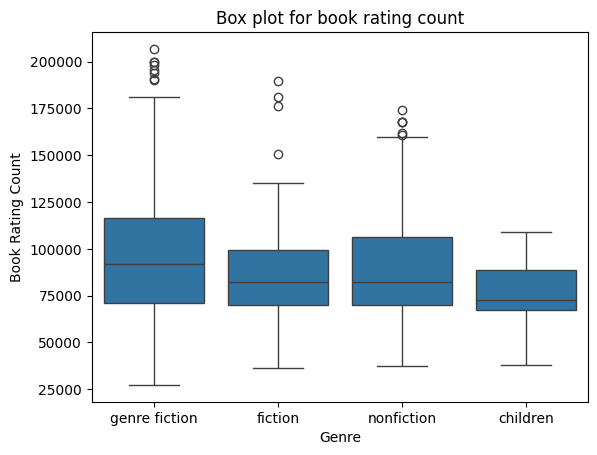

In [44]:
# Create a boxplot for booking rating count for each genre 
sns.boxplot(x = "genre",y = "Book_ratings_count", data = df)
plt.xlabel("Genre")
plt.ylabel("Book Rating Count")
plt.title("Box plot for book rating count")
plt.show()

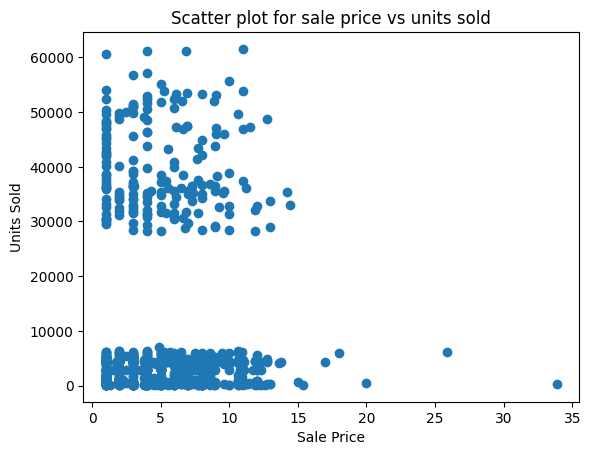

In [49]:
# Scatter plot for sale price  and units sold
plt.scatter(df["sale price"],df["units sold"])
plt.xlabel("Sale Price")
plt.ylabel("Units Sold")
plt.title ("Scatter plot for sale price vs units sold")
plt.show()



In [54]:
# let us get the value count of the language code
df["language_code"].value_counts()


language_code
eng      670
en-US    226
en-GB     29
en-CA      7
fre        4
spa        2
ara        2
nl         1
Name: count, dtype: int64

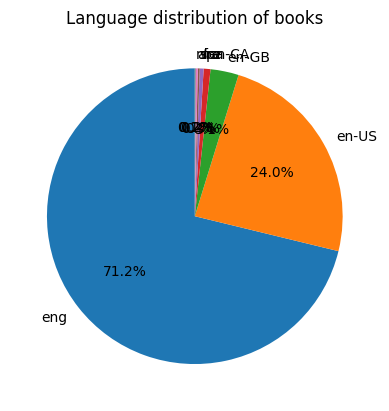

In [62]:
# Create a pie chart for
language_counts = df["language_code"].value_counts()
plt.pie(language_counts,labels = language_counts.index,startangle = 90, autopct = "%1.1f%%")
plt.title("Language distribution of books")
plt.show()
        

In [66]:
df.groupby("Publisher ")["publisher revenue"].sum().sort_values(ascending = False)


Publisher 
Penguin Group (USA) LLC                 191581.104
Random House LLC                        174956.244
Amazon Digital Services,  Inc.          141767.772
HarperCollins Publishers                121769.814
Hachette Book Group                     107410.968
Simon and Schuster Digital Sales Inc     46858.206
Macmillan                                31249.830
HarperCollins Publishing                  2830.806
HarperCollins Christian Publishing        2135.670
Name: publisher revenue, dtype: float64

In [74]:
df.groupby("Author_Rating")["Book_ratings_count"].mean().sort_values(ascending = False).head(1)


Author_Rating
Intermediate    101400.272569
Name: Book_ratings_count, dtype: float64

In [77]:
# Group by language code and count the number  of books in each language
df.groupby("language_code").size().sort_values(ascending = False)

language_code
eng      670
en-US    226
en-GB     29
en-CA      7
fre        4
ara        2
spa        2
nl         1
dtype: int64

In [79]:
# Group by Author rating and find the max book rating count for author rating
df.groupby("Author_Rating")["Book_ratings_count"].max()


Author_Rating
Excellent       167848
Famous          206792
Intermediate    199872
Novice          155903
Name: Book_ratings_count, dtype: int64

In [80]:
df.groupby("Author_Rating")["Book_ratings_count"].min()

Author_Rating
Excellent       32626
Famous          54977
Intermediate    27308
Novice          42339
Name: Book_ratings_count, dtype: int64

In [81]:
df.groupby("Author_Rating")["Book_ratings_count"].std()

Author_Rating
Excellent       21023.456069
Famous          35036.475144
Intermediate    34210.096082
Novice          30859.612389
Name: Book_ratings_count, dtype: float64

In [82]:
df.groupby("Author_Rating")["Book_ratings_count"].median()

Author_Rating
Excellent       81609.5
Famous          90527.0
Intermediate    98254.5
Novice          77446.5
Name: Book_ratings_count, dtype: float64

In [83]:
df.groupby("Author_Rating")["Book_ratings_count"].var()

Author_Rating
Excellent       4.419857e+08
Famous          1.227555e+09
Intermediate    1.170331e+09
Novice          9.523157e+08
Name: Book_ratings_count, dtype: float64

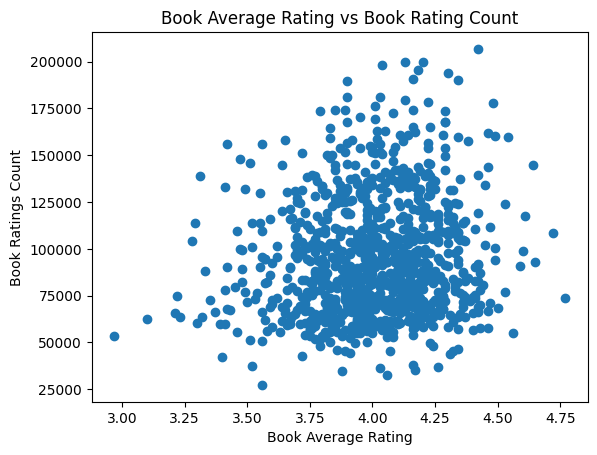

In [85]:
plt.scatter(df["Book_average_rating"],df["Book_ratings_count"])
plt.xlabel("Book Average Rating")
plt.ylabel("Book Ratings Count")
plt.title("Book Average Rating vs Book Rating Count")
plt.show()

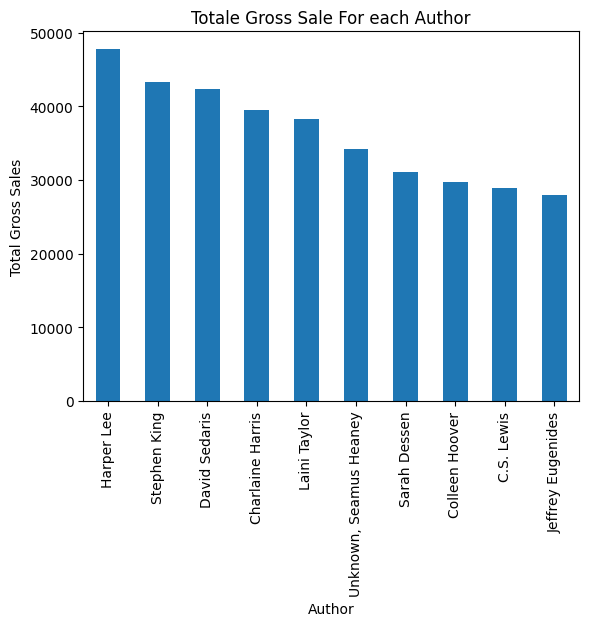

In [91]:
# Let us create a bar chart of the total gross sales for each author
total_gross_sale_by_each_author = df.groupby("Author")["gross sales"].sum()
total_gross_sale_by_each_author.sort_values(ascending = False).head(10).plot(kind="bar")
plt.xlabel("Author")
plt.ylabel("Total Gross Sales")
plt.title("Totale Gross Sale For each Author")
plt.show()
                                                                    


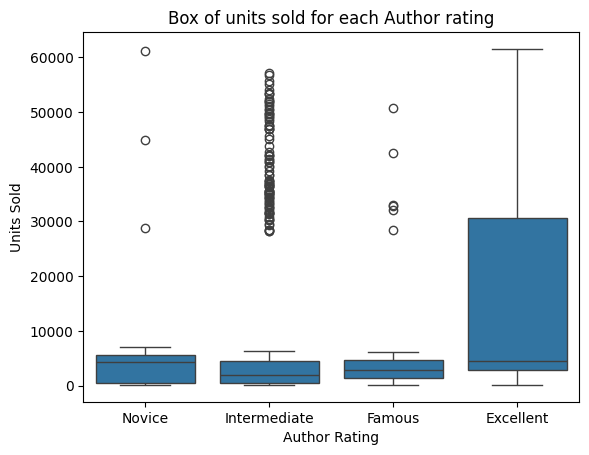

In [93]:
sns.boxplot(x ="Author_Rating", y = "units sold", data = df)
plt.xlabel("Author Rating")
plt.ylabel("Units Sold")
plt.title("Box of units sold for each Author rating")
plt.show()

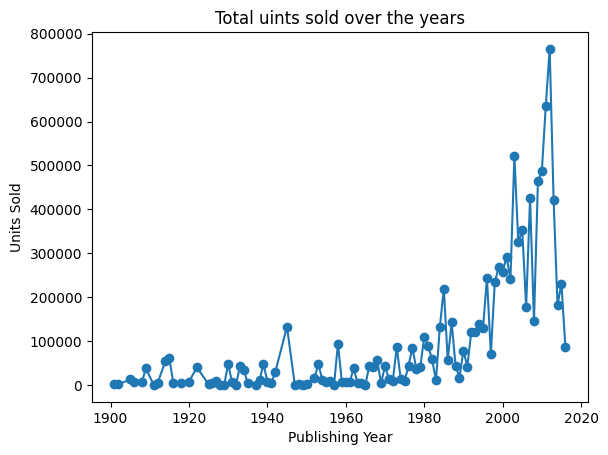

In [95]:
# create line chart
# group our data by publsihing year and unit sold
df.groupby("Publishing Year")["units sold"].sum().plot(kind = "line", marker = "o")
plt.xlabel("Publishing Year")
plt.ylabel("Units Sold")
plt.title("Total uints sold over the years")
plt.show()